In [3]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.3 MB/s eta 0:00:00


# **Import library**

In [4]:
import networkx as nx
from  networkx.algorithms import approximation as approx
import networkx.algorithms.connectivity as conn
import random
import pandas as pd
import time
import math
import gc
import sys
from collections import deque, defaultdict
import copy
import networkx as nx
import osmnx as ox
from networkx.algorithms.flow.capacityscaling import capacity_scaling
from networkx.algorithms.bridges import bridges
from networkx.classes.function import nodes
from  networkx.algorithms import approximation as approx
import networkx.algorithms.connectivity as conn
import numpy as np
import matplotlib.pyplot as plt
from networkx.algorithms.flow import edmonds_karp
from networkx.algorithms.flow import preflow_push
from networkx.algorithms.flow import dinitz_alg
from networkx.algorithms.flow import dinitz

# **Save parameters of graph**

In [ ]:
res = {
"Ville": "place",
"Noeuds (n)":" n,",
"Aretes (m)": "m",
"Densite": "density",
"Degre moyen": "degree_avg",
"Degre min": "degree_min",
"Degre max": "degree_max",
"Composantes connexes": "num_components",
"Diametre": "diameter",
"Clustering moyen": "clustering_avg",
"Centralite degre (moy)": "degree_centrality",
"Centralite intermediarite (moy)": "betweenness_avg",
"Centralite proximite (moy)": "closeness",
"Longueur totale (m)": "edge_length_total",
"Longueur moyenne (m)": "edge_length_avg"
        }


In [ ]:
#path = "/home/mael/Téléchargements/Mael/Memoire/"
cities = ["bruges_Belgique.graphml",
          "Venise_Italie.graphml",
          "Oxford_Angleterre.graphml",
          "Dakar_Senegal.graphml", "Kigali_Rwanda.graphml",
          "Mons_Belgique.graphml", "marseille_France.graphml",
         "Johor_Bahru_Malaysia.graphml"]

city = [city for city in cities]
cities_without_extension = [city.split('/')[-1].split('.')[0] for city in cities]
graphs = open_graphml(city)

In [ ]:
def analyze_city_graph(cities, graph):
    """
    Analyse une collection de graphes routiers OSMnx et calcule leurs métriques principales.

    Args:
        cities: Liste des noms de villes associés aux graphes.
        graph: Liste des graphes OSMnx à analyser.

    Returns:
        Un DataFrame pandas contenant une ligne de métriques par ville.
    """
    result = []
    for place, G in zip(cities, graph):
        copy_dict = res.copy()

        # Certaines métriques sont calculées sur une version non orientée et simplifiée du graphe.
        G_undirected = G.to_undirected()
        G_simple = nx.Graph(G_undirected)

        n = G.number_of_nodes()
        m = G.number_of_edges()

        degrees = [deg for node, deg in G.degree()]

        degree_avg = np.mean(degrees)
        degree_min = np.min(degrees)
        degree_max = np.max(degrees)

        density = nx.density(G)
        num_components = nx.number_connected_components(G_simple)

        if num_components == 1:
            diameter = nx.diameter(G_simple)
        else:
            diameter = None

        clustering_avg = nx.average_clustering(G_simple)
        degree_centrality = np.mean(list(nx.degree_centrality(G_simple).values()))

        # On approxime la betweenness pour garder un temps de calcul raisonnable sur les grands graphes.
        betweenness = nx.betweenness_centrality(G_simple, k=min(500, n), normalized=True)
        betweenness_avg = np.mean(list(betweenness.values()))

        closeness = np.mean(list(nx.closeness_centrality(G_simple).values()))

        edge_lengths = [data.get("length", 0) for u, v, data in G.edges(data=True)]
        edge_length_total = np.sum(edge_lengths)
        edge_length_avg = np.mean(edge_lengths)
        copy_dict["ville"] = place
        print(copy_dict["ville"])
        copy_dict["Noeuds (n)"] = n
        copy_dict["Aretes (m)"] = m
        copy_dict["Degre moyen"] = degree_avg
        copy_dict["Degre min"] = degree_min
        copy_dict["Degre max"] = degree_max
        copy_dict["Densite"] = density
        copy_dict["Composantes connexes"] = num_components
        copy_dict["Diametre"] = diameter
        copy_dict["Clustering moyen"] = clustering_avg
        copy_dict["Centralite degre (moy)"] = degree_centrality
        copy_dict["Centralite intermediarite (moy)"] = betweenness_avg
        copy_dict["Centralite proximite (moy)"] = closeness
        copy_dict["Longueur totale (m)"] = edge_length_total
        copy_dict["Longueur moyenne (m)"] = edge_length_avg
        result.append(copy_dict)

    df = pd.DataFrame(result)
    return df



df_results = analyze_city_graph(cities_without_extension, graphs)
print("\nRésumé des métriques :")
print(df_results)

# Export CSV pour Overleaf
df_results.to_csv("graph_metrics_annexe.csv", index=False)

print("\nFichier 'graph_metrics_annexe.csv' généré.")


# **Build and plot the graph**

In [5]:
def download(places):
    """
    Télécharge les graphes routiers OSMnx pour une liste de lieux.

    Args:
        places: Liste des lieux à télécharger.

    Returns:
        Une liste de graphes OSMnx simplifiés de type `drive`.
    """
    return [ox.graph_from_place(place, network_type="drive", simplify=True, retain_all=False) for place in places]


In [ ]:
def open_graphml(filenames):
    """
    Charge plusieurs graphes enregistrés au format GraphML.

    Args:
        filenames: Liste des chemins de fichiers GraphML.

    Returns:
        Une liste de graphes NetworkX/OSMnx chargés depuis le disque.
    """
    return [ox.load_graphml(filename) for filename in filenames]


In [ ]:
def plot_graph(graphs, places):
    """
    Affiche une visualisation OSMnx pour chaque graphe fourni.

    Args:
        graphs: Liste des graphes à afficher.
        places: Liste des titres à associer à chaque graphe.

    Returns:
        Une liste de couples `(fig, ax)` générés pour chaque graphe.
    """

    plots = []
    for G, place in zip(graphs, places):
        fig, ax = ox.plot_graph(
            G,
            node_size=10,
            bgcolor="white",
            node_color="black",
            edge_color="green",
            edge_linewidth=0.5,
            show=False,
            close=False,
        )
        ax.set_title(place)
        plots.append((fig, ax))
        plt.show()
    return plots



In [ ]:
def save_graphs(graphs, places):
    """
    Enregistre une liste de graphes au format GraphML.

    Args:
        graphs: Liste des graphes à sauvegarder.
        places: Liste des noms de lieux utilisés pour générer les noms de fichiers.
    """
    for G, place in zip(graphs, places):
        filename = f"{place.replace(',', '').replace(' ', '_')}.graphml"
        ox.save_graphml(G, filename)



In [ ]:
def save_graphs_as_png(graphs, places):
    """
    Exporte une image PNG pour chaque graphe fourni.

    Args:
        graphs: Liste des graphes à représenter.
        places: Liste des noms utilisés pour les titres et fichiers de sortie.
    """
    for G, place in zip(graphs, places):
        # Chaque figure est créée séparément pour éviter les réécritures de rendu.
        fig, ax = ox.plot_graph(
            G,
            node_size=10,
            bgcolor="white",
            node_color="black",
            edge_color="green",
            edge_linewidth=0.5,
            show=False,
            close=False,
        )
        ax.set_title(place)
        filename = f"{place.replace(',', '').replace(' ', '_')}.png"
        fig.savefig(filename, dpi=300)
        plt.close(fig)
        print(f"Saved {filename}")


In [ ]:
places = [
    #"bruges, Belgique",
    #"Venise, Italie",
    #"tokyo, japan",
    #"barcelone, espagne",
    #"Oxford, Angleterre",
    #"Dakar, Senegal",
    #"new-york , usa",
    #"Kigali, Rwanda",
    "Nimy, Belgique",
    "Gosselies, Belgique",
    "Obourg, Belgique"
    ]
result = download(places)
#save_graphs(result,places)
#save_graphs_as_png(result, places)
#plot_graph(result,places)
#result

In [ ]:
def save_graphs(graphs, places):
    """
    Enregistre une liste de graphes au format GraphML.

    Args:
        graphs: Liste des graphes à sauvegarder.
        places: Liste des noms de lieux utilisés pour générer les noms de fichiers.
    """
    for G, place in zip(graphs, places):
        filename = f"{place.replace(',', '').replace(' ', '_')}.graphml"
        ox.save_graphml(G, filename)


In [ ]:
save_graphs(result,places)

In [5]:
for place, G in zip(places,result):
  print(place,ox.basic_stats(G))
for place, G in zip(places,result):
  print(place, nx.density(G))

Nimy, Belgique {'n': 149, 'm': 332, 'k_avg': 4.456375838926174, 'edge_length_total': 43718.31247660395, 'edge_length_avg': 131.68166408615647, 'streets_per_node_avg': 2.7114093959731544, 'streets_per_node_counts': {0: 0, 1: 27, 2: 3, 3: 106, 4: 12, 5: 1}, 'streets_per_node_proportions': {0: 0.0, 1: 0.18120805369127516, 2: 0.020134228187919462, 3: 0.7114093959731543, 4: 0.08053691275167785, 5: 0.006711409395973154}, 'intersection_count': 122, 'street_length_total': 24576.48509337836, 'street_segment_count': 192, 'street_length_avg': 128.00252652801228, 'circuity_avg': 1.0995052869853161, 'self_loop_proportion': 0.005208333333333333}
Gosselies, Belgique {'n': 448, 'm': 909, 'k_avg': 4.058035714285714, 'edge_length_total': 118576.80450328025, 'edge_length_avg': 130.44752970657893, 'streets_per_node_avg': 2.857142857142857, 'streets_per_node_counts': {0: 0, 1: 54, 2: 4, 3: 344, 4: 44, 5: 2}, 'streets_per_node_proportions': {0: 0.0, 1: 0.12053571428571429, 2: 0.008928571428571428, 3: 0.7678

In [6]:
def get_info_on_edges(graphs, places):
    """
    Récupère un extrait des arêtes de chaque graphe avec leurs attributs.

    Args:
        graphs: Liste des graphes à inspecter.
        places: Liste des noms associés aux graphes.

    Returns:
        Une liste de tuples `(lieu, arêtes)` contenant les trois premières arêtes de chaque graphe.
    """
    res = []
    for place, G in zip(places, graphs):
        res.append((place, list(G.edges(data=True))[:3]))
    return res

info = get_info_on_edges(result, places)
info


[('Nimy, Belgique',
  [(9094067,
    1366957524,
    {'osmid': 122291704,
     'highway': 'motorway_link',
     'lanes': '1',
     'oneway': True,
     'reversed': False,
     'length': np.float64(21.944826974750363)}),
   (9094067,
    380978184,
    {'osmid': 657839095,
     'highway': 'primary',
     'lanes': '1',
     'maxspeed': '50',
     'name': 'Rue des Viaducs',
     'oneway': True,
     'ref': 'N6',
     'reversed': False,
     'length': np.float64(107.17435858268021),
     'geometry': <LINESTRING (3.954 50.483, 3.953 50.483, 3.953 50.483)>}),
   (204902686,
    1234917900,
    {'osmid': 19716377,
     'highway': 'motorway_link',
     'lanes': '1',
     'maxspeed': '70',
     'oneway': True,
     'reversed': False,
     'length': np.float64(576.8170391833252),
     'geometry': <LINESTRING (3.955 50.484, 3.955 50.485, 3.955 50.485, 3.954 50.485, 3.954 5...>})]),
 ('Gosselies, Belgique',
  [(29685663,
    6520605458,
    {'osmid': 23034174,
     'highway': 'motorway_link',
    

# **Remove all nodes of degree 1, to improve connexity**

In [7]:
def remove_nodes_of_degree_one(graph, places):
    """
    Supprime les nœuds de degré 1 dans chaque graphe non orienté.

    Args:
        graph: Liste des graphes à nettoyer.
        places: Liste des noms associés aux graphes.

    Returns:
        Un dictionnaire dont la clé contient le lieu et le graphe nettoyé,
        et la valeur un résumé des suppressions effectuées.
    """
    result = {}
    for G, place in zip(graph, places):
        initial_node_count = G.number_of_nodes()
        G_ox_undirected = G.to_undirected()

        nodes_to_remove = [node for node, degree in dict(G_ox_undirected.degree()).items() if degree == 1]
        G_ox_undirected.remove_nodes_from(nodes_to_remove)

        final_node_count = G_ox_undirected.number_of_nodes()
        removed_count = len(nodes_to_remove)
        result[place, G_ox_undirected] = (
            "initial_node_count :",
            initial_node_count,
            "removed_count:",
            removed_count,
            "final_node_count:",
            final_node_count,
        )
    return result


In [8]:
nodes_removed = remove_nodes_of_degree_one(result,places)
nodes_removed

{('Nimy, Belgique',
  <networkx.classes.multigraph.MultiGraph at 0x788984cc9a90>): ('initial_node_count :',
  149,
  'removed_count:',
  32,
  'final_node_count:',
  117),
 ('Gosselies, Belgique',
  <networkx.classes.multigraph.MultiGraph at 0x788984ccbb90>): ('initial_node_count :',
  448,
  'removed_count:',
  58,
  'final_node_count:',
  390),
 ('Obourg, Belgique',
  <networkx.classes.multigraph.MultiGraph at 0x788984cc8a10>): ('initial_node_count :',
  87,
  'removed_count:',
  12,
  'final_node_count:',
  75)}

In [9]:
#Trouver la plus grande composante connexe
def find_largest_connected_component(graph):
    """
    Extrait la plus grande composante connexe de chaque graphe si nécessaire.

    Args:
        graph: Dictionnaire produit par `remove_nodes_of_degree_one`.

    Returns:
        Un dictionnaire associant chaque lieu au graphe connexe retenu et à sa connectivité par arêtes.
    """
    res = {}
    datas = [data for data in graph.keys()]
    for place, G_ox_undirected in datas:
        if not nx.is_connected(G_ox_undirected):
            largest_cc_nodes = max(nx.connected_components(G_ox_undirected), key=len)
            H_ox = G_ox_undirected.subgraph(largest_cc_nodes).copy()
            res[place] = H_ox, conn.edge_connectivity(H_ox)
        else:
            H_ox = G_ox_undirected.copy()
            res[place] = H_ox, conn.edge_connectivity(H_ox)
    return res


In [10]:
largest_component = find_largest_connected_component(nodes_removed)
largest_component

{'Nimy, Belgique': (<networkx.classes.multigraph.MultiGraph at 0x78898a018620>,
  1),
 'Gosselies, Belgique': (<networkx.classes.multigraph.MultiGraph at 0x7889961acfe0>,
  1),
 'Obourg, Belgique': (<networkx.classes.multigraph.MultiGraph at 0x78898517e6f0>,
  1)}

In [11]:
for place, G in largest_component.items():
  print(place, G[0])

Nimy, Belgique MultiGraph with 117 nodes and 161 edges
Gosselies, Belgique MultiGraph with 390 nodes and 564 edges
Obourg, Belgique MultiGraph with 75 nodes and 105 edges


#***Selecting the source and sink using the northernmost node as the source and the southernmost node as the sink***

In [12]:
def connect_north_south_extremes(G, top_k=5):
    """
    Relie les nœuds les plus au nord et au sud aux nœuds centraux les plus pertinents.

    La sélection priorise d'abord la betweenness centrality, puis la distance topologique.

    Args:
        G: Graphe à modifier.
        top_k: Nombre de connexions à ajouter pour chaque extrémité.

    Returns:
        Un tuple contenant le graphe modifié, le nœud nord et le nœud sud.
    """
    speed = [(20, 1), (30, 1), (50, 2), (50, 1), (70, 2), (90, 2), (90, 3), (120, 2), (120, 3)]

    north_node = max(G.nodes, key=lambda n: G.nodes[n]['y'])
    south_node = min(G.nodes, key=lambda n: G.nodes[n]['y'])

    if isinstance(G, (nx.MultiDiGraph, nx.MultiGraph)):
        G_simple = nx.Graph(G)
    else:
        G_simple = G

    bc = nx.betweenness_centrality(G_simple, weight=None)
    bc.pop(north_node, None)
    bc.pop(south_node, None)

    dist_north = nx.single_source_shortest_path_length(G_simple, north_node)
    dist_south = nx.single_source_shortest_path_length(G_simple, south_node)

    def select_nodes(distances, excluded_nodes):
        """
        Sélectionne les meilleurs candidats selon la centralité puis la distance.

        Args:
            distances: Distances topologiques depuis le nœud extrême courant.
            excluded_nodes: Ensemble de nœuds à ignorer.

        Returns:
            La liste des nœuds retenus pour ajouter de nouvelles arêtes.
        """
        candidates = []

        for node, centrality in bc.items():
            if node in excluded_nodes:
                continue
            if node not in distances:
                continue
            candidates.append((node, centrality, distances[node]))

        candidates.sort(key=lambda x: (-x[1], -x[2]))
        selected = [node for node, _, _ in candidates[:top_k]]
        return selected

    selected_north = select_nodes(dist_north, excluded_nodes=set())
    selected_south = select_nodes(dist_south, excluded_nodes=set(selected_north))

    # Les nouvelles arêtes reçoivent des paramètres de vitesse et de voies simulés.
    for node in selected_north:
        random.shuffle(speed)
        val = random.choice(speed)
        G.add_edge(north_node, node, maxspeed=val[0], lane=val[1])

    for node in selected_south:
        random.shuffle(speed)
        val = random.choice(speed)
        G.add_edge(south_node, node, maxspeed=val[0], lane=val[1])

    return G, north_node, south_node


In [13]:
def compute_source_sink(graphs_dict, k):
    """
    Calcule les couples source/puits à partir des extrémités nord et sud de chaque graphe.

    Args:
        graphs_dict: Dictionnaire de graphes par lieu.
        k: Nombre de connexions à ajouter pour chaque extrémité.

    Returns:
        Un tuple contenant les graphes modifiés et les couples `(source, sink)` par lieu.
    """
    result_graph = {}
    result_source_sink = {}
    for place, G in graphs_dict.items():
        G, north_node, south_node = connect_north_south_extremes(G[0], k)
        result_graph[place] = G
        result_source_sink[place] = (north_node, south_node)

    return result_graph, result_source_sink


In [14]:
result_graph, result_source_sink = compute_source_sink(largest_component,4)

#***Selection of the source and sink by using maximum degree method***

In [ ]:
#Compute the maximum distance between each node  that have degre >3 and take only the couple that are the most far
def max_distance_high_degre_pairs_fast(G, degree):
    """
    Recherche les paires de nœuds de degré élevé les plus éloignées dans le graphe.

    Args:
        G: Graphe dans lequel calculer les distances.
        degree: Dictionnaire `{noeud: degré}`.

    Returns:
        Un dictionnaire des paires maximisant la distance topologique.
    """
    valid_nodes = [n for n, bc in degree.items() if bc >= 3]

    max_distance = -1
    result = {}

    for u in valid_nodes:
        lengths = nx.single_source_shortest_path_length(G, u)

        for v in valid_nodes:
            if u == v:
                continue
            if v in lengths:
                dist = lengths[v]
                if dist > max_distance:
                    max_distance = dist
                    result = {(u, v): dist}
                elif dist == max_distance:
                    result[(u, v)] = dist

    return result


In [ ]:
def get_nodes_sorted_by_degree(graphs_dict):
    """
    Trie les nœuds par degré puis retient les paires les plus éloignées pour chaque graphe.

    Args:
        graphs_dict: Dictionnaire de graphes par lieu.

    Returns:
        Un dictionnaire associant chaque lieu aux paires de nœuds sélectionnées.
    """
    all_sorted_nodes = {}
    for place, graph in graphs_dict.items():
        # On trie d'abord les nœuds par degré avant de filtrer les paires les plus éloignées.
        degrees = dict(graph.degree())
        sorted_nodes = dict(sorted(degrees.items(), key=lambda item: item[1], reverse=True))
        far_degrees = max_distance_high_degre_pairs_fast(graph, sorted_nodes)

        all_sorted_nodes[place] = far_degrees
    return all_sorted_nodes

# Example usage with your 'result' variable (which contains a list of graphs)
sorted_nodes_list = get_nodes_sorted_by_degree(add_capacity)
for place, node in sorted_nodes_list.items():
  print(f"Graph {place} nodes sorted by degree (descending): {list(node.items())[:10]} (showing top 10)")


Graph Nimy, Belgique nodes sorted by degree (descending): [((221049023, 1199869177), 28), ((1113327881, 1199869177), 28), ((1199869177, 221049023), 28), ((1199869177, 1113327881), 28)] (showing top 10)
Graph Gosselies, Belgique nodes sorted by degree (descending): [((1194347060, 5814693476), 48), ((5814693476, 1194347060), 48)] (showing top 10)
Graph Obourg, Belgique nodes sorted by degree (descending): [((1588533898, 4171742276), 16), ((4171742276, 1588533898), 16)] (showing top 10)


In [ ]:
souce_sink = get_nodes_sorted_by_degree(add_capacity)
tuples_nimy, j= list(souce_sink['Nimy, Belgique'].keys())[0]
print(tuples_nimy,j)


221049023 1199869177


#***Selection of the source and sink by using betweenness connected method***

In [ ]:
#Compute the maximum distance between each node  that have betweenness_centrality >0 and take only the couple that are the most far
def max_distance_high_betweenness_pairs_fast(G, betweenness):
    """
    Recherche les paires de nœuds à betweenness positive les plus éloignées.

    Args:
        G: Graphe dans lequel calculer les distances.
        betweenness: Dictionnaire `{noeud: centralité}`.

    Returns:
        Un dictionnaire des paires maximisant la distance topologique.
    """
    valid_nodes = [n for n, bc in betweenness.items() if bc > 0]

    max_distance = -1
    result = {}

    for u in valid_nodes:
        lengths = nx.single_source_shortest_path_length(G, u)

        for v in valid_nodes:
            if u == v:
                continue
            if v in lengths:
                dist = lengths[v]
                if dist > max_distance:
                    max_distance = dist
                    result = {(u, v): dist}
                elif dist == max_distance:
                    result[(u, v)] = dist

    return result


In [ ]:
def get_nodes_sorted_by_betweenness_centrality(graphs_dict):
    """
    Trie les nœuds par betweenness centrality puis retient les paires les plus éloignées.

    Args:
        graphs_dict: Dictionnaire de graphes par lieu.

    Returns:
        Un dictionnaire associant chaque lieu aux paires de nœuds sélectionnées.
    """
    all_sorted_nodes = {}
    for place, graph in graphs_dict.items():
        # Même logique que pour le degré, mais avec la centralité d'intermédiarité.
        d = nx.betweenness_centrality(graph)
        sorted_dict = dict(sorted(d.items(), key=lambda item: item[1], reverse=True))
        far_degrees = max_distance_high_betweenness_pairs_fast(graph, sorted_dict)

        all_sorted_nodes[place] = far_degrees
    return all_sorted_nodes

# Example usage with your 'result' variable (which contains a list of graphs)
sorted_nodes_list = get_nodes_sorted_by_betweenness_centrality(add_capacity)
for place, node in sorted_nodes_list.items():
  print(f"Graph {place} : {list(node.items())[:10]}")


Graph Nimy, Belgique : [((1113327881, 1199869177), 28), ((1199869177, 1113327881), 28), ((1199869177, 221049023), 28), ((1199869177, 1113248209), 28), ((221049023, 1199869177), 28), ((1113248209, 1199869177), 28)]
Graph Gosselies, Belgique : [((1194347060, 5814693476), 48), ((5814693476, 1194347060), 48)]
Graph Obourg, Belgique : [((1588533898, 4171742275), 15), ((4171742275, 1588533898), 15), ((4171742275, 1588476022), 15), ((4171742275, 1588476012), 15), ((1588476022, 4171742275), 15), ((1588476012, 4171742275), 15)]


In [ ]:
souce_sink = get_nodes_sorted_by_degree(add_capacity)
tuples_nimy, j= list(souce_sink['Nimy, Belgique'].keys())[0]
print(tuples_nimy,j)


(1193224677,
 1194593999,
 {(1193224677, 1194593999): 5, (1194593999, 1193224677): 5})

# **Compute capacity of each edge**

In [15]:
#Compute capacity for each edge
def compute_capacity(graph):
  """
  Calcule une capacité théorique pour chaque arête à partir du nombre de voies et de la vitesse.

  Args:
      graph: Dictionnaire de graphes multi-arêtes par lieu.

  Returns:
      Le même dictionnaire de graphes enrichi avec l'attribut `capacity` sur chaque arête.
  """
  result = {}
  for place, G in graph.items():
    for u, v, k, data in G.edges(keys=True, data=True):

      lanes = data.get("lanes", 1)

      # Les attributs OSM peuvent être stockés sous plusieurs formats ; on les normalise ici.
      if isinstance(lanes, list):
          vals = []
          for l in lanes:
              try:
                  vals.append(int(str(l).split()[0]))
              except:
                  pass
          lanes = max(vals) if vals else 1

      elif isinstance(lanes, str):
          vals = []
          for part in lanes.split(";"):
              try:
                  vals.append(int(part.strip()))
              except:
                  pass
          lanes = max(vals) if vals else 1

      else:
          try:
              lanes = int(lanes)
          except:
              lanes = 1

      maxspeed = data.get("maxspeed", 50)

      if isinstance(maxspeed, list):
          vals = []
          for s in maxspeed:
              try:
                  vals.append(int(str(s).split()[0]))
              except:
                  pass
          maxspeed = max(vals) if vals else 50

      else:
          try:
              maxspeed = int(str(maxspeed).split()[0])
          except:
              maxspeed = 50

      capacity = 1800 * lanes * (maxspeed / 50)
      data["capacity"] = capacity

    result[place] = G
  return result


In [16]:
compute_capacity(result_graph)

{'Nimy, Belgique': <networkx.classes.multigraph.MultiGraph at 0x78898a018620>,
 'Gosselies, Belgique': <networkx.classes.multigraph.MultiGraph at 0x7889961acfe0>,
 'Obourg, Belgique': <networkx.classes.multigraph.MultiGraph at 0x78898517e6f0>}

In [17]:
#Attribute capacity at each edge
def add_capacity(graph):
  """
  Agrège les capacités d'un multigraphe dans un graphe simple non orienté.

  Args:
      graph: Dictionnaire de graphes contenant l'attribut `capacity` sur les arêtes.

  Returns:
      Un dictionnaire de graphes simples avec une capacité cumulée par arête.
  """
  result = {}
  for place, G_original in graph.items():
    H = nx.Graph()
    if hasattr(G_original, 'graph'):
        H.graph.update(G_original.graph)

    # Les multi-arêtes sont fusionnées en sommant leurs capacités.
    for u, v, key, data in G_original.edges(keys=True, data=True):
        cap = data.get("capacity", 0)
        if H.has_edge(u, v):
            H[u][v]["capacity"] += cap
        else:
            H.add_edge(u, v, capacity=cap)
    result[place] = H
  return result


In [18]:
graphs_with_capacity = compute_capacity(result_graph)
add_capacity = add_capacity(graphs_with_capacity)
add_capacity

{'Nimy, Belgique': <networkx.classes.graph.Graph at 0x788985062660>,
 'Gosselies, Belgique': <networkx.classes.graph.Graph at 0x78898516a5d0>,
 'Obourg, Belgique': <networkx.classes.graph.Graph at 0x788985062600>}

In [30]:
for G in add_capacity.values():
  res = list(G.edges(data=True))[:3]
print(res)


[(286689120, 286689123, {'capacity': 1800.0}), (286689120, 388301728, {'capacity': 3600.0}), (286689120, 286689130, {'capacity': 1800.0})]


# **Run multiples algorithms for comparing execution time**

In [19]:
def get_graphs(graphs_dict):
    """
    Associe à chaque graphe son couple source/puits pour les calculs de flot.

    Args:
        graphs_dict: Dictionnaire de graphes par lieu.

    Returns:
        Un dictionnaire `{lieu: (graphe, source, sink)}`.
    """
    all_graphs = {}
    for place, graph in graphs_dict.items():
      source, sink = result_source_sink[place]
      all_graphs[place] = (graph, source, sink)
      if nx.has_path(graph, source, sink):
        pass
      else:
        print("no path exist")
    return all_graphs

algos = {
    "Edmonds-Karp": nx.algorithms.flow.edmonds_karp,
    "Dinic": nx.algorithms.flow.dinitz,
    "Push-Relabel": nx.algorithms.flow.preflow_push
}


In [20]:
graphs = get_graphs(add_capacity)
graphs

{'Nimy, Belgique': (<networkx.classes.graph.Graph at 0x788985062660>,
  715553013,
  462714989),
 'Gosselies, Belgique': (<networkx.classes.graph.Graph at 0x78898516a5d0>,
  5814693474,
  829531519),
 'Obourg, Belgique': (<networkx.classes.graph.Graph at 0x788985062600>,
  4171742276,
  1069566135)}

In [21]:
def benchmark_maxflow(G, s, t, flow_func, runs=5, modified_edge=None):
    """
    Mesure le temps d'exécution moyen d'un algorithme de flot maximum.

    Args:
        G: Graphe NetworkX sur lequel exécuter l'algorithme.
        s: Nœud source.
        t: Nœud puits.
        flow_func: Fonction de calcul du flot maximum.
        runs: Nombre de répétitions pour la mesure.
        modified_edge: Tuple optionnel `(u, v, new_capacity)` pour tester une variation de capacité.

    Returns:
        Un dictionnaire contenant la valeur du flot et le temps moyen mesuré.
    """

    times = []
    flow_value = None

    for _ in range(runs):
        gc.collect()

        # Chaque exécution repart d'une copie propre du graphe.
        G_test = G.copy()

        if modified_edge is not None:
            u, v, new_capacity = modified_edge

            if not G_test.has_edge(u, v):
                raise ValueError("Arête inexistante dans le graphe")

            G_test[u][v]["capacity"] = new_capacity

        start = time.perf_counter()

        flow_value, _ = nx.maximum_flow(
            G_test,
            s,
            t,
            flow_func=flow_func,
            capacity="capacity"
        )

        end = time.perf_counter()
        times.append(end - start)

    return {
        "flow_value": flow_value,
        "mean_time": sum(times) / runs,
    }


In [ ]:
P = nx.DiGraph()
P.add_edge("x", "a", capacity=3.0)
P.add_edge("x", "b", capacity=1.0)
P.add_edge("a", "c", capacity=3.0)
P.add_edge("b", "c", capacity=5.0)
P.add_edge("b", "d", capacity=4.0)
P.add_edge("d", "e", capacity=2.0)
P.add_edge("c", "y", capacity=2.0)
P.add_edge("e", "y", capacity=3.0)
R = dinitz(P, "x", "y")
flow_value = nx.maximum_flow_value(P, "x", "y")
flow_value

In [22]:
def build_graph(graphs_dict):
    """
    Exécute les algorithmes de flot max sur chaque graphe et collecte les graphes résiduels.

    Args:
        graphs_dict: Dictionnaire `{lieu: (graphe, source, sink)}`.

    Returns:
        Un tuple `(résultats, graphes_résiduels)` indexé par lieu puis par algorithme.
    """
    all_results = {}
    residual_graph  = {}
    for gname, (G, s, t) in graphs_dict.items():
        num_edges = G.number_of_edges()
        all_results[gname] = {}
        residual_graph[gname] = {}

        for aname, algo in algos.items():
            Residual = algo(G, s, t, capacity="capacity")
            res = benchmark_maxflow(G, s, t, algo, runs=7)
            all_results[gname][aname] = (res["mean_time"] / num_edges) * 1e6
            residual_graph[gname][aname] = Residual
    return all_results, residual_graph


In [23]:
result, residual = build_graph(graphs)

In [36]:
result

{'Nimy, Belgique': {'Edmonds-Karp': 11.834823579892474,
  'Dinic': 10.40191222016554,
  'Push-Relabel': 21.366728054664843},
 'Gosselies, Belgique': {'Edmonds-Karp': 17.344256078994686,
  'Dinic': 25.040531154869367,
  'Push-Relabel': 26.263754052520046},
 'Obourg, Belgique': {'Edmonds-Karp': 10.550466836251388,
  'Dinic': 15.268832907729436,
  'Push-Relabel': 22.459723214519634}}

In [47]:
residual

dict_items([('Nimy, Belgique', {'Edmonds-Karp': <networkx.classes.digraph.DiGraph object at 0x7f1faa5eb110>, 'Dinic': <networkx.classes.digraph.DiGraph object at 0x7f1faa5ea300>, 'Push-Relabel': <networkx.classes.digraph.DiGraph object at 0x7f1faa5eaf90>}), ('Gosselies, Belgique', {'Edmonds-Karp': <networkx.classes.digraph.DiGraph object at 0x7f1faa5e9790>, 'Dinic': <networkx.classes.digraph.DiGraph object at 0x7f1faa62a930>, 'Push-Relabel': <networkx.classes.digraph.DiGraph object at 0x7f1faa62aa80>}), ('Obourg, Belgique', {'Edmonds-Karp': <networkx.classes.digraph.DiGraph object at 0x7f1fa0a7f2c0>, 'Dinic': <networkx.classes.digraph.DiGraph object at 0x7f1faa6f14c0>, 'Push-Relabel': <networkx.classes.digraph.DiGraph object at 0x7f1faa62a030>})])

In [ ]:
#Plot results
def plot_results(all_results):
    """
    Trace un histogramme comparant les temps moyens normalisés des algorithmes de flot.

    Args:
        all_results: Dictionnaire des performances par graphe et par algorithme.
    """
    graph_names = list(all_results.keys())
    algo_names = list(algos.keys())

    x = np.arange(len(graph_names))
    width = 0.25

    plt.figure(figsize=(8, 4))

    for i, algo in enumerate(algo_names):
        values = [all_results[g][algo] for g in graph_names]
        bars = plt.bar(x + i * width, values, width, label=algo)

        for bar, val in zip(bars, values):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    plt.xticks(x + width, graph_names)
    plt.ylabel("Temps moyen normalisé (µs / arête)")
    plt.title("Comparaison des algorithmes de flot\nsur plusieurs graphes")
    plt.legend()
    plt.tight_layout()
    plt.show()


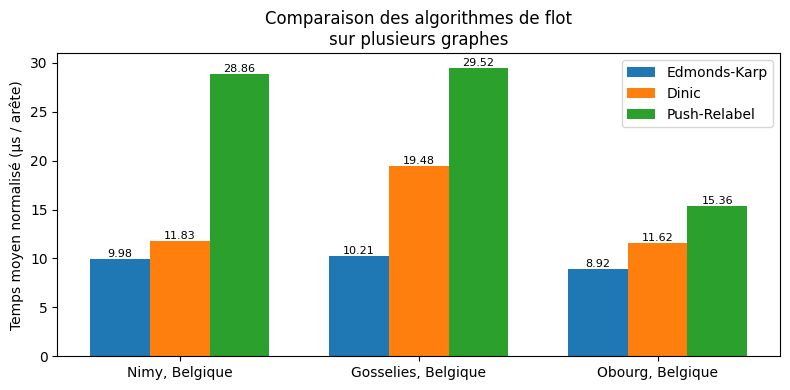

In [ ]:
plot_results(build_graph(graphs))

In [ ]:
# Affichage des performances
def print_performance(benchmark_results):
  """
  Affiche les performances normalisées de chaque algorithme par graphe.

  Args:
      benchmark_results: Dictionnaire des résultats produit par `build_graph`.
  """
  print("Performance Results:")
  for graph_name, algo_times in benchmark_results.items():
    print(f"\n--- {graph_name} ---")
    for algo_name, time_per_edge in algo_times.items():
      print(f"{algo_name:15s}: {time_per_edge:.2f} µs / edge")


In [ ]:
print_performance(build_graph(graphs))

Performance Results:

--- Nimy, Belgique ---
Edmonds-Karp   : 10.74 µs / edge
Dinic          : 14.17 µs / edge
Push-Relabel   : 37.33 µs / edge

--- Gosselies, Belgique ---
Edmonds-Karp   : 39.96 µs / edge
Dinic          : 53.09 µs / edge
Push-Relabel   : 32.06 µs / edge

--- Obourg, Belgique ---
Edmonds-Karp   : 12.02 µs / edge
Dinic          : 23.77 µs / edge
Push-Relabel   : 35.92 µs / edge


In [ ]:
#Verifier que tous les algos retournent le même flot max
def check_results(results):
  """
  Affiche la valeur de flot calculée pour chaque algorithme.

  Args:
      results: Dictionnaire de résultats contenant une clé `flow_value` par algorithme.
  """
  for name, res in results.items():
      print(f"{name:20s} → flow = {res['flow_value']}")


#***Dynamic Flow : Edmonds-Karp, Dinic, Push-Relabel***

In [24]:
class DynamicEdmondsKarp_New:
    """Implémentation simple d'un Edmonds-Karp recalculé après mise à jour de capacité."""

    def __init__(self, G, source, sink, capacity_attr_name='capacity'):
        """
        Initialise l'algorithme avec un graphe, une source et un puits.

        Args:
            G: Graphe orienté ou non orienté supportant les attributs d'arêtes.
            source: Nœud source.
            sink: Nœud puits.
            capacity_attr_name: Nom de l'attribut de capacité sur les arêtes.
        """
        self.G = G.copy()
        self.s = source
        self.t = sink
        self.capacity_attr_name = capacity_attr_name

        # On complète le graphe pour disposer d'arêtes inverses nécessaires au résiduel.
        for u_node, v_node, data in self.G.edges(data=True):
            if self.capacity_attr_name not in data:
                data[self.capacity_attr_name] = 1
            data['flow'] = 0

            if not self.G.has_edge(v_node, u_node):
                self.G.add_edge(v_node, u_node, **{self.capacity_attr_name: 0, 'flow': 0})

        self.flow_value = 0
        self._edmonds_karp()

    def _bfs(self):
        """
        Cherche un chemin augmentant dans le graphe résiduel.

        Returns:
            Un dictionnaire des parents si un chemin existe, sinon `None`.
        """
        parent = {self.s: None}
        queue = deque([self.s])

        while queue:
            u = queue.popleft()
            for v in self.G.neighbors(u):
                residual_cap = self.G[u][v].get(self.capacity_attr_name, 0) - self.G[u][v].get('flow', 0)

                if v not in parent and residual_cap > 0:
                    parent[v] = u
                    if v == self.t:
                        return parent
                    queue.append(v)
        return None

    def _augment(self, parent):
        """
        Augmente le flot le long d'un chemin trouvé par BFS.

        Args:
            parent: Dictionnaire des parents décrivant le chemin augmentant.
        """
        path_flow = float('inf')
        v = self.t
        path = []

        while v != self.s:
            u = parent[v]
            path.append((u, v))
            residual_cap = self.G[u][v].get(self.capacity_attr_name, 0) - self.G[u][v].get('flow', 0)
            path_flow = min(path_flow, residual_cap)
            v = u
        path.reverse()

        # Le flux est poussé dans le sens direct et retiré sur l'arête inverse.
        for u_node, v_node in path:
            self.G[u_node][v_node]['flow'] += path_flow
            self.G[v_node][u_node]['flow'] -= path_flow

        self.flow_value += path_flow

    def _edmonds_karp(self):
        """Exécute Edmonds-Karp jusqu'à saturation de tous les chemins augmentants."""
        while True:
            parent = self._bfs()
            if parent is None:
                break
            self._augment(parent)

    def get_max_flow(self):
        """Retourne la valeur actuelle du flot maximum calculé."""
        return self.flow_value

    def update_edge_capacity(self, u, v, new_capacity_value):
        """
        Met à jour la capacité d'une arête puis recalcule le flot maximum.

        Args:
            u: Nœud source de l'arête.
            v: Nœud cible de l'arête.
            new_capacity_value: Nouvelle capacité à affecter.
        """
        if self.G.has_edge(u, v):
            self.G[u][v][self.capacity_attr_name] = new_capacity_value
        else:
            self.G.add_edge(u, v, **{self.capacity_attr_name: new_capacity_value, 'flow': 0})
            if not self.G.has_edge(v, u):
                self.G.add_edge(v, u, **{self.capacity_attr_name: 0, 'flow': 0})

        # Cette version repart d'un flot nul après modification plutôt qu'une mise à jour incrémentale.
        for u_node, v_node in self.G.edges():
            self.G[u_node][v_node]['flow'] = 0
        self.flow_value = 0
        self._edmonds_karp()


In [25]:
class IncrementalDinicFlow_new:
    """Wrapper autour de Dinic avec support d'une mise à jour de capacité sur le graphe résiduel."""

    def __init__(self, G, source, sink, capacity_attr_name='capacity'):
        """
        Initialise la structure incrémentale basée sur Dinic.

        Args:
            G: Graphe de départ.
            source: Nœud source.
            sink: Nœud puits.
            capacity_attr_name: Nom de l'attribut de capacité.
        """
        self.G_original = G.copy()
        self.source = source
        self.sink = sink
        self.capacity_attr_name = capacity_attr_name

        for u, v, data in self.G_original.edges(data=True):
            if 'flow' not in data:
                data['flow'] = 0

        self.residual_graph = nx.algorithms.flow.dinitz(
            self.G_original,
            self.source,
            self.sink,
            capacity=self.capacity_attr_name
        )

        self.flow_value = self.residual_graph.graph["flow_value"]

    def get_max_flow(self):
        """Retourne la valeur actuelle du flot maximum."""
        return self.flow_value

    def _res_cap(self, u, v) -> int:
        """
        Calcule la capacité résiduelle d'une arête.

        Args:
            u: Nœud source de l'arête.
            v: Nœud cible de l'arête.

        Returns:
            La capacité encore disponible sur l'arête dans le graphe résiduel.
        """
        if not self.residual_graph.has_edge(u, v):
            return 0
        d = self.residual_graph[u][v]
        return d[self.capacity_attr_name] - d["flow"]

    def _current_flow_value(self) -> int:
        """
        Recalcule la valeur de flot courante depuis les arêtes sortant de la source.

        Returns:
            La somme des flux positifs en sortie de la source.
        """
        return sum(
            d["flow"] for _, _, d in self.residual_graph.out_edges(self.source, data=True) if d["flow"] > 0
        )

    def _cancel_flow_on_path(self, path: list, amount: int):
        """
        Annule une quantité de flot le long d'un chemin donné.

        Args:
            path: Liste ordonnée de nœuds formant le chemin.
            amount: Quantité de flot à retirer.
        """
        for i in range(len(path) - 1):
            u, v = path[i], path[i + 1]
            self.residual_graph[u][v]["flow"] -= amount
            self.residual_graph[v][u]["flow"] += amount

    def _find_path_with_flow(self, start, end) -> tuple[list, int]:
        """
        Recherche un chemin portant déjà du flot positif entre deux nœuds.

        Args:
            start: Nœud de départ.
            end: Nœud d'arrivée.

        Returns:
            Un tuple `(chemin, bottleneck)` ou `([], 0)` si aucun chemin n'est trouvé.
        """
        prev: dict = {}
        visited = {start}
        q = deque([start])
        while q:
            u = q.popleft()
            if u == end:
                path = []
                node = end
                while node != start:
                    parent = prev[node]
                    path.append(node)
                    node = parent
                path.append(start)
                path.reverse()

                # Le bottleneck limite la quantité de flot que l'on peut annuler sur ce chemin.
                bottleneck = math.inf
                for i in range(len(path)-1):
                    u_path, v_path = path[i], path[i+1]
                    if "flow" in self.residual_graph[u_path][v_path]:
                        bottleneck = min(bottleneck, self.residual_graph[u_path][v_path]["flow"])
                    else:
                        bottleneck = 0
                        break
                if bottleneck == math.inf:
                    bottleneck = 0
                return path, bottleneck
            for v in self.residual_graph.successors(u):
                if v not in visited and self.residual_graph[u][v].get("flow", 0) > 0:
                    visited.add(v)
                    prev[v] = u
                    q.append(v)
        return [], 0

    def _cancel_excess(self, start, end, excess: int):
        """
        Annule progressivement un excès de flot entre deux nœuds.

        Args:
            start: Nœud de départ de l'annulation.
            end: Nœud d'arrivée de l'annulation.
            excess: Quantité de flot à annuler.
        """
        while excess > 0:
            path, bottleneck = self._find_path_with_flow(start, end)
            if not path or bottleneck == 0:
                break
            to_cancel = min(excess, bottleneck)
            self._cancel_flow_on_path(path, to_cancel)
            excess -= to_cancel

    def update_edge_capacity(self, u, v, new_cap: int):
        """
        Met à jour la capacité d'une arête et réutilise le résiduel lorsque c'est possible.

        Args:
            u: Nœud source de l'arête.
            v: Nœud cible de l'arête.
            new_cap: Nouvelle capacité à appliquer.
        """
        if not self.residual_graph.has_edge(u, v):
            raise ValueError(f"L'arête ({u}, {v}) n'existe pas dans le graphe résiduel.")

        current_flow_ab = self.residual_graph[u][v].get("flow", 0)
        excess = current_flow_ab - new_cap

        if excess <= 0:
            self.residual_graph[u][v][self.capacity_attr_name] = new_cap
            self.residual_graph = nx.algorithms.flow.dinitz(
                self.G_original,
                self.source,
                self.sink,
                capacity=self.capacity_attr_name,
                residual=self.residual_graph
            )
            self.flow_value = self.residual_graph.graph["flow_value"]
        else:
            # Si la nouvelle capacité viole le flot courant, on annule d'abord l'excès utilisable.
            self._cancel_excess(v, self.sink, excess)
            self._cancel_excess(self.source, u, excess)

            self.residual_graph[u][v][self.capacity_attr_name] = new_cap
            self.residual_graph[u][v]["flow"] = new_cap
            if not self.residual_graph.has_edge(v, u):
                self.residual_graph.add_edge(v, u, **{self.capacity_attr_name: 0, 'flow': 0})
            self.residual_graph[v][u]["flow"] = -new_cap

            self.flow_value = self._current_flow_value()

            self.residual_graph = nx.algorithms.flow.dinitz(
                self.G_original,
                self.source,
                self.sink,
                capacity=self.capacity_attr_name,
                residual=self.residual_graph
            )
            self.flow_value = self.residual_graph.graph["flow_value"]


In [26]:
class IncrementalPreflowPushFlow_New:
    """Wrapper autour de Preflow-Push avec mise à jour de capacité sur le résiduel."""

    def __init__(self, G, source, sink, capacity_attr_name='capacity'):
        """
        Initialise la structure incrémentale basée sur Preflow-Push.

        Args:
            G: Graphe de départ.
            source: Nœud source.
            sink: Nœud puits.
            capacity_attr_name: Nom de l'attribut de capacité.
        """
        self.G_original = G.copy()
        self.source = source
        self.sink = sink
        self.capacity_attr_name = capacity_attr_name

        for u, v, data in self.G_original.edges(data=True):
            if 'flow' not in data:
                data['flow'] = 0

        self.residual_graph = nx.algorithms.flow.preflow_push(
            self.G_original,
            self.source,
            self.sink,
            capacity=self.capacity_attr_name
        )

        self.flow_value = self.residual_graph.graph["flow_value"]

    def get_max_flow(self):
        """Retourne la valeur actuelle du flot maximum."""
        return self.flow_value

    def _res_cap(self, u, v) -> int:
        """
        Calcule la capacité résiduelle d'une arête.

        Args:
            u: Nœud source de l'arête.
            v: Nœud cible de l'arête.

        Returns:
            La capacité encore disponible sur l'arête dans le graphe résiduel.
        """
        if not self.residual_graph.has_edge(u, v):
            return 0
        d = self.residual_graph[u][v]
        return d[self.capacity_attr_name] - d["flow"]

    def _current_flow_value(self) -> int:
        """
        Recalcule la valeur de flot courante depuis les arêtes sortant de la source.

        Returns:
            La somme des flux positifs en sortie de la source.
        """
        return sum(
            d["flow"] for _, _, d in self.residual_graph.out_edges(self.source, data=True) if d["flow"] > 0
        )

    def _cancel_flow_on_path(self, path: list, amount: int):
        """
        Annule une quantité de flot le long d'un chemin donné.

        Args:
            path: Liste ordonnée de nœuds formant le chemin.
            amount: Quantité de flot à retirer.
        """
        for i in range(len(path) - 1):
            u, v = path[i], path[i + 1]
            self.residual_graph[u][v]["flow"] -= amount
            self.residual_graph[v][u]["flow"] += amount

    def _find_path_with_flow(self, start, end) -> tuple[list, int]:
        """
        Recherche un chemin portant déjà du flot positif entre deux nœuds.

        Args:
            start: Nœud de départ.
            end: Nœud d'arrivée.

        Returns:
            Un tuple `(chemin, bottleneck)` ou `([], 0)` si aucun chemin n'est trouvé.
        """
        prev: dict = {}
        visited = {start}
        q = deque([start])
        while q:
            u = q.popleft()
            if u == end:
                path = []
                node = end
                while node != start:
                    parent = prev[node]
                    path.append(node)
                    node = parent
                path.append(start)
                path.reverse()

                # Le bottleneck limite la quantité de flot que l'on peut annuler sur ce chemin.
                bottleneck = math.inf
                for i in range(len(path)-1):
                    u_path, v_path = path[i], path[i+1]
                    if "flow" in self.residual_graph[u_path][v_path]:
                        bottleneck = min(bottleneck, self.residual_graph[u_path][v_path]["flow"])
                    else:
                        bottleneck = 0
                        break
                if bottleneck == math.inf:
                    bottleneck = 0
                return path, bottleneck
            for v in self.residual_graph.successors(u):
                if v not in visited and self.residual_graph[u][v].get("flow", 0) > 0:
                    visited.add(v)
                    prev[v] = u
                    q.append(v)
        return [], 0

    def _cancel_excess(self, start, end, excess: int):
        """
        Annule progressivement un excès de flot entre deux nœuds.

        Args:
            start: Nœud de départ de l'annulation.
            end: Nœud d'arrivée de l'annulation.
            excess: Quantité de flot à annuler.
        """
        while excess > 0:
            path, bottleneck = self._find_path_with_flow(start, end)
            if not path or bottleneck == 0:
                break
            to_cancel = min(excess, bottleneck)
            self._cancel_flow_on_path(path, to_cancel)
            excess -= to_cancel

    def update_edge_capacity(self, u, v, new_cap: int):
        """
        Met à jour la capacité d'une arête et relance Preflow-Push à partir du résiduel courant.

        Args:
            u: Nœud source de l'arête.
            v: Nœud cible de l'arête.
            new_cap: Nouvelle capacité à appliquer.
        """
        if not self.residual_graph.has_edge(u, v):
            raise ValueError(f"L'arête ({u}, {v}) n'existe pas dans le graphe résiduel.")

        current_flow_ab = self.residual_graph[u][v].get("flow", 0)
        excess = current_flow_ab - new_cap

        if excess <= 0:
            self.residual_graph[u][v][self.capacity_attr_name] = new_cap
            self.residual_graph = nx.algorithms.flow.preflow_push(
                self.G_original,
                self.source,
                self.sink,
                capacity=self.capacity_attr_name,
                residual=self.residual_graph
            )
            self.flow_value = self.residual_graph.graph["flow_value"]
        else:
            # Même logique que Dinic : on retire d'abord l'excès de flot devenu invalide.
            self._cancel_excess(v, self.sink, excess)
            self._cancel_excess(self.source, u, excess)

            self.residual_graph[u][v][self.capacity_attr_name] = new_cap
            self.residual_graph[u][v]["flow"] = new_cap

            if not self.residual_graph.has_edge(v, u):
                self.residual_graph.add_edge(v, u, **{self.capacity_attr_name: 0, 'flow': 0})
            self.residual_graph[v][u]["flow"] = -new_cap

            self.flow_value = self._current_flow_value()

            self.residual_graph = nx.algorithms.flow.preflow_push(
                self.G_original,
                self.source,
                self.sink,
                capacity=self.capacity_attr_name,
                residual=self.residual_graph
            )
            self.flow_value = self.residual_graph.graph["flow_value"]


# **Compute bridges and select one of them**

In [27]:
def search_bridges(graph_dict):
  """
  Sélectionne un pont aléatoire dans chaque graphe.

  Args:
      graph_dict: Dictionnaire de graphes simples par lieu.

  Returns:
      Un dictionnaire associant chaque lieu à une arête qui est un pont.
  """
  result = {}
  for place, graph in graph_dict.items():
    bridges = list(nx.bridges(graph))
    random.shuffle(bridges)
    selected_bridge = random.choice(bridges)
    result[place] = selected_bridge
  return result


In [28]:
selected_bridges = search_bridges(add_capacity)
selected_bridges

{'Nimy, Belgique': (9846903885, 1635336409),
 'Gosselies, Belgique': (1194347008, 1194347060),
 'Obourg, Belgique': (1069566135, 4707020540)}

# **Run dynamics algorithms and plot histogram of the mofied graph**

In [29]:
def get_dynamic_graphs(graphs_dict):
    """
    Associe à chaque graphe dynamique son couple source/puits.

    Args:
        graphs_dict: Dictionnaire de graphes par lieu.

    Returns:
        Un dictionnaire `{lieu: (graphe, source, sink)}` pour les benchmarks dynamiques.
    """
    all_graphs = {}
    for place, graph in graphs_dict.items():
      source, sink = result_source_sink[place]
      all_graphs[place] = (graph, source, sink)
      if nx.has_path(graph, source, sink):
        pass
      else:
        print("no path exist")
    return all_graphs

algos = {
    "Edmonds-Karp": DynamicEdmondsKarp_New,
    "Dinic": IncrementalDinicFlow_new,
    "Push-Relabel": IncrementalPreflowPushFlow_New
}


In [30]:
dynamic_graphs = get_dynamic_graphs(add_capacity)
dynamic_graphs

{'Nimy, Belgique': (<networkx.classes.graph.Graph at 0x788985062660>,
  715553013,
  462714989),
 'Gosselies, Belgique': (<networkx.classes.graph.Graph at 0x78898516a5d0>,
  5814693474,
  829531519),
 'Obourg, Belgique': (<networkx.classes.graph.Graph at 0x788985062600>,
  4171742276,
  1069566135)}

In [31]:
def benchmark_maxflow_dynamic(G_original, s, t, AlgoClass, runs=5, modified_edge=None):
    """
    Mesure le coût d'initialisation ou de mise à jour d'un algorithme dynamique de flot max.

    Args:
        G_original: Graphe original copié à chaque exécution.
        s: Nœud source.
        t: Nœud puits.
        AlgoClass: Classe implémentant l'algorithme dynamique.
        runs: Nombre de répétitions pour la mesure.
        modified_edge: Tuple optionnel `(u, v, new_capacity)` décrivant la modification à appliquer.

    Returns:
        Un dictionnaire contenant la valeur de flot et le temps moyen mesuré.
    """
    times = []
    flow_value = None

    if modified_edge is None:
        for _ in range(runs):
            gc.collect()
            G_copy_for_init = G_original.copy()
            start = time.perf_counter()
            algo_instance = AlgoClass(G_copy_for_init, s, t, capacity_attr_name="capacity")
            flow_value = algo_instance.get_max_flow()
            end = time.perf_counter()
            times.append(end - start)
    else:
        u, v, new_capacity = modified_edge
        for _ in range(runs):
            gc.collect()
            # Chaque mesure repart d'un état initial indépendant avant d'appliquer la mise à jour.
            G_copy_for_run = G_original.copy()
            algo_instance = AlgoClass(G_copy_for_run, s, t, capacity_attr_name="capacity")

            if not G_copy_for_run.has_edge(u, v) and not G_copy_for_run.has_edge(v, u):
                raise ValueError(f"Edge ({u}, {v}) not found in graph for dynamic update benchmark.")

            start = time.perf_counter()
            algo_instance.update_edge_capacity(u, v, new_capacity)
            flow_value = algo_instance.get_max_flow()
            end = time.perf_counter()
            times.append(end - start)

    return {
        "flow_value": flow_value,
        "mean_time": sum(times) / runs,
    }


In [35]:
def build_dynamic_graph(graphs_dict, graphs_dict_original, list_capacity):
  """
  Lance les benchmarks des variantes dynamiques de flot maximum.

  Args:
      graphs_dict: Dictionnaire `{lieu: (graphe, source, sink)}` pour les graphes modifiés.
      graphs_dict_original: Dictionnaire des graphes résiduels ou graphes d'origine selon l'algorithme.
      list_capacity: Liste des nouvelles capacités à tester pour chaque graphe.

  Returns:
      Un dictionnaire des temps moyens normalisés par graphe et par algorithme.
  """
  all_results = {}
  graph_only_dict = {gname: G_residual for gname, (G_residual, s, t) in graphs_dict.items()}

  bridges = search_bridges(graph_only_dict)

  if len(list_capacity) != len(graphs_dict):
      raise ValueError("The number of capacities in list_capacity must match the number of graphs.")

  for i, elem in enumerate(zip(graphs_dict.items(), graphs_dict_original.items())):
      num_edges = elem[0][1][0].number_of_edges()
      u, v = bridges[elem[0][0]]
      new_bridge_capacity = list_capacity[i]

      all_results[elem[0][0]] = {}

      for aname, algo_class in algos.items():
        if aname == "Edmonds-Karp":
          res = benchmark_maxflow_dynamic(
              elem[1][1]['Edmonds-Karp'],
              elem[0][1][1],
              elem[0][1][2],
              algo_class,
              runs=7,
              modified_edge=(u, v, new_bridge_capacity),
          )
          all_results[elem[0][0]][aname] = (res["mean_time"] / num_edges)
        else:
          G, s, t = elem[0][1]
          res = benchmark_maxflow_dynamic(G, s, t, algo_class, runs=7)
          all_results[elem[0][0]][aname] = (res["mean_time"] / num_edges) * 1e6

  return all_results


In [69]:
  for i, d in enumerate(zip(graphs.items(), residual.items())):
    print(d[0][1][0])

Graph with 117 nodes and 166 edges
Graph with 390 nodes and 564 edges
Graph with 75 nodes and 112 edges


In [36]:
cap  = [20,20,20]
build_dynamic_graph(dynamic_graphs,residual,cap)

{'Nimy, Belgique': {'Edmonds-Karp': 6.675027538356536e-06,
  'Dinic': 14.617018072301157,
  'Push-Relabel': 43.04677366614236},
 'Gosselies, Belgique': {'Edmonds-Karp': 1.880511854116809e-05,
  'Dinic': 23.332447568489776,
  'Push-Relabel': 33.32655648389951},
 'Obourg, Belgique': {'Edmonds-Karp': 2.4172963008470325e-05,
  'Dinic': 36.757691326997424,
  'Push-Relabel': 31.60409821308646}}

In [37]:
#Plot results
def plot_dynamic_results(all_results):
    """
    Trace un histogramme des performances des algorithmes dynamiques de flot.

    Args:
        all_results: Dictionnaire des performances par graphe et par algorithme.
    """
    graph_names = list(all_results.keys())
    algo_names = list(algos.keys())

    x = np.arange(len(graph_names))
    width = 0.25

    plt.figure(figsize=(8, 4))

    for i, algo in enumerate(algo_names):
        values = [all_results[g][algo] for g in graph_names]
        bars = plt.bar(x + i * width, values, width, label=algo)

        for bar, val in zip(bars, values):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    plt.xticks(x + width, graph_names)
    plt.ylabel("Temps moyen normalisé (µs / arête)")
    plt.title("Comparaison des algorithmes dynamiques de flot\nsur plusieurs graphes")
    plt.legend()
    plt.tight_layout()
    plt.show()


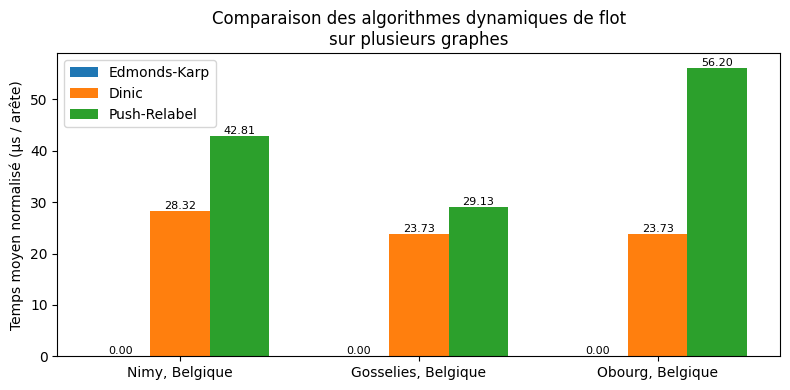

In [39]:
plot_dynamic_results(build_dynamic_graph(dynamic_graphs,residual,cap))

In [ ]:
# Affichage des performances
def print_performance(all_results):
  """
  Recalcule et retourne les benchmarks de flot pour chaque graphe.

  Args:
      all_results: Paramètre conservé pour compatibilité avec l'appel existant.

  Returns:
      Une liste de tuples `(nom_du_graphe, résultats_des_algorithmes)`.
  """
  results = {}
  res = []
  for names, graph in get_graphs(add_capacity).items():
    for name, algo in algos.items():
      G, source, sink = graph
      results[name] = benchmark_maxflow(G, source, sink, algo, runs=7)
    res.append((names, results))
  return res


In [ ]:
print_performance(build_dynamic_graph((add_capacity),cap))

# **test**